In [ ]:
# Classification
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

models = {
    # Baseline: satu pohon keputusan
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    # Bagging: 100 pohon dilatih paralel dengan data acak berbeda
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    # Boosting: pohon dilatih berurutan, memperbaiki error model sebelumnya
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "accuracy:", round(accuracy_score(y_test, pred), 3))

DecisionTree accuracy: 0.947
RandomForest accuracy: 0.965
GradientBoosting accuracy: 0.956


In [ ]:
# Regression
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Dataset Diabetes: 442 pasien, 10 fitur, target = ukuran perkembangan penyakit.
db = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    db.data, db.target, test_size=0.2, random_state=42
)

# Melatih Random Forest Regressor lalu memprediksi
reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
pred = reg.predict(X_test)

# RMSE = error rata-rata (satuan sama dengan target); R² = seberapa cocok model (0–1).
print("RMSE:", round(root_mean_squared_error(y_test, pred), 3))
print("R2:", round(r2_score(y_test, pred), 3))

RMSE: 54.332
R2: 0.443


#Tujuan Program
Pratikum ini bertujuan untuk mengimlentasikan dan membandingkat performa berbagai algoritma Ensemble Learning, yaitu DEcision Tree, Random Forest, dan juga Gradient Boosting, dalam mengklasifikasikan besaran tip pelanggan. Melalui program ini, dialkukan analisis fitur untuk menentukan faktor paling berpengaruh terhadap prediksi tip serta menguji pengaruh jumlah pohon (n_estimators) terhadap stabilitas akurasi modelnya.

#Langkah Kerja
1. Preparasi data yang digunakan untuk memuat dataset, melakukan label encoding pada data kategorikal, dan membuat target biner berdasarkan median tip.
2. Data Splitting yang digunakan untuk membagi data menjadi dua yaitu training set dan test set dengan proporsi 80% dan 20%.
3. Melatih dan membandingkan akurasi dari tiga model klasifikasi yang berbeda.
4. Mengekstraksikan fitur terpenting menggunakan atribut feature importances dari model Random Forest.
5. Melakukan iterasi pengujian pengaruh jumlah n_estimators terhadap akurasi model.
6. Membuat visualisasi hasil fitur terpenting dan grafik pengaruh n_estimators serta menarik kesimpulan akhir.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# =================================================================
# PREPARASI DATA
# =================================================================
df = sns.load_dataset('tips')

# Encoding data kategorikal agar bisa diproses model
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['day'] = le.fit_transform(df['day'])
df['time'] = le.fit_transform(df['time'])

# Target: 1 jika tip di atas median, 0 jika tidak
df['tip_binary'] = np.where(df['tip'] > df['tip'].median(), 1, 0)

X = df.drop(columns=['tip', 'tip_binary'])
y = df['tip_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Pada program ini digunakan untuk memuat dataset tips agar data kategorikal seperti jenis kelamin dan hari diubah menjadi angka menggunakan perintah LabelEncoder. Target prediksi dibuat menjadi biner (1 untk tip tinggi, 0 untuk tip rendah) berdasarkan nilai mediannya.
hasilnya yaitu data berhasil disiapkan dalam bentuk numerik sepenuhnya. Dimana variabel x menampung fitur input dan variabel y menampung targrt biner, dan dataset siap digunakan dalam proses pelatihan model.

In [2]:
# =================================================================
# 1. BANDINGKAN MODEL (CLASSIFICATION)
# =================================================================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("--- NOMOR 1: Perbandingan Akurasi ---")
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name} Accuracy: {acc:.2%}")

--- NOMOR 1: Perbandingan Akurasi ---
Decision Tree Accuracy: 61.22%
Random Forest Accuracy: 73.47%
Gradient Boosting Accuracy: 75.51%


Pada program ini digunakan untuk membandikan akurasi dari tiga model klasifikasi. Model Ensemble (Random Forest dan Gradient Boosting) diuji untuk melihat apakah mereka memberikan hasil yang lebih baik dari pada model tunggal (Decision Tree).
Hasil outputnya yaitu menampilkan presentase akurasi untuk ketiga model. Pada hasil ini memberikan gambaran bahwa model mana yang paling kuat dalam memprediksi data uji yang diberikan. Model yang paling kuat yaitu model Random Forest dan Gradient Boosting.

In [3]:
# =================================================================
# 2. 10 FITUR TERPENTING (RANDOM FOREST)
# =================================================================
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\n--- NOMOR 2: Fitur Terpenting ---")
print(feature_importance_df.head(10))



--- NOMOR 2: Fitur Terpenting ---
      Feature  Importance
0  total_bill    0.703572
5        size    0.112771
3         day    0.080709
2      smoker    0.042787
1         sex    0.035323
4        time    0.024839


Di program ini, saya menganalisis fitur mana yang paling berpengaruh dalam menentukan besaran tip menggunakan model Random Forest.
Hasil outputnya yaitu berupa urutan fitur dari yang paling penting hingga yang kurang berpengaruh. Hal ini sangat berguna untuk kita memahami variabel kunci dala dataset tips.

In [12]:
# =================================================================
# 3. PENGARUH N_ESTIMATORS
# =================================================================
n_list = [1, 10, 50, 100, 200, 500]
n_scores = []

for n in n_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    n_scores.append(accuracy_score(y_test, rf_temp.predict(X_test)))

# Tambahkan baris ini jika ingin melihat angka skornya langsung:
print("Skor akurasi untuk setiap n_estimators:")
for n, score in zip(n_list, n_scores):
    print(f"n_estimators = {n}: Accuracy = {score:.4f}")

Skor akurasi untuk setiap n_estimators:
n_estimators = 1: Accuracy = 0.6122
n_estimators = 10: Accuracy = 0.7143
n_estimators = 50: Accuracy = 0.7551
n_estimators = 100: Accuracy = 0.7347
n_estimators = 200: Accuracy = 0.7347
n_estimators = 500: Accuracy = 0.7551


Pada program ini digunakan untuk menguji bagaimana penambahan jumlah pohon (estimators) pada random Fores mempengaruhi tingkat akurasi model.
Hasil dari proses ini yaitu menghasilkan sekumpulan skor akurasi yang akan menunjukkan tren performa seiring bertambahnya jumlah pohon dalam model.

/tmp/ipykernel_255/2717301289.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


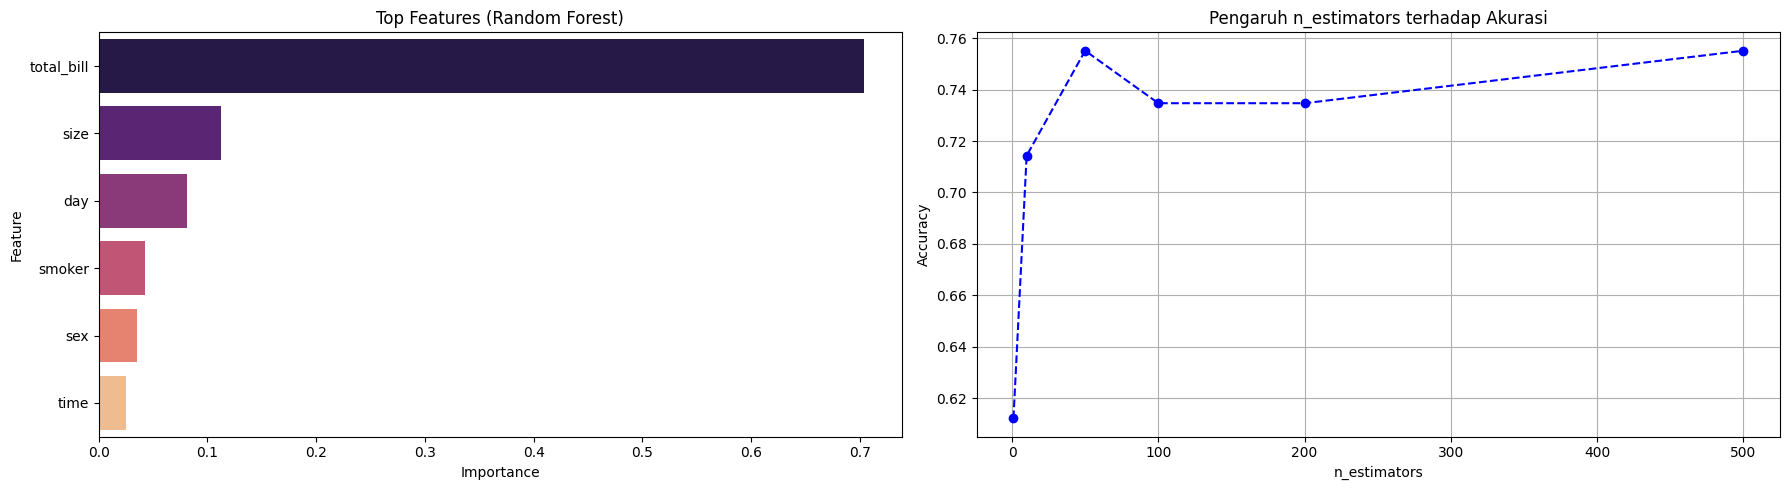


--- KESIMPULAN ---
1. Perbandingan: Gradient Boosting dan Random Forest biasanya lebih unggul dari Decision Tree karena mengurangi risiko overfitting.
2. Fitur: Total Bill merupakan faktor penentu utama dalam memprediksi besaran tip.
3. n_estimators: Menambah jumlah pohon meningkatkan stabilitas akurasi, namun setelah titik tertentu akurasi cenderung stagnan.


In [10]:
# =================================================================
# 4. VISUALISASI DAN KESIMPULAN
# =================================================================
plt.figure(figsize=(18, 5))

# Plot Fitur Terpenting
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top Features (Random Forest)')

# Plot Pengaruh n_estimators
plt.subplot(1, 2, 2)
plt.plot(n_list, n_scores, marker='o', linestyle='--', color='b')
plt.title('Pengaruh n_estimators terhadap Akurasi')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- KESIMPULAN ---")
print("1. Perbandingan: Gradient Boosting dan Random Forest biasanya lebih unggul dari Decision Tree karena mengurangi risiko overfitting.")
print("2. Fitur: Total Bill merupakan faktor penentu utama dalam memprediksi besaran tip.")
print("3. n_estimators: Menambah jumlah pohon meningkatkan stabilitas akurasi, namun setelah titik tertentu akurasi cenderung stagnan.")

Pada bagian terakhir ini digunakan untuk memvisualisasikan data penting ke dalam bentuk grafis agar lebih mudah dianalisis dan di tarik kesimpulan akhirnya.
Hasil outputnya menunjukan secara jelas bahwa total_bill adalah fitur yang paling dominan. Selain itu, grafik garis menunjukkan bahwa akurasi akan meningkat dan menjadi stabil seiring bertambahnya nilai pada n_estimators.

#Kesimpulan
Pada program ini, dapat disimpulkan bahwa penggunaan metode Ensemble seperi Random Forest dan Gradient Boosting terbukti lebih stabil dibandingkan Decision Tree tunggal. Pada penentuan fitur yang terpenting yaitu membantu kita fokus pda variabel yang paing relevan bagi bisnis, sementara pengujian hyperparameter pohon memberikan wawasan tentang efisiensi komputasi model yang diangun.